# M4/Т5: Information retrieval

In [1]:
import contextlib
import csv
import io
import json
import math
import os
import random
import re
import sys
import time
from pathlib import Path

import nltk
import numpy as np
import pandas as pd
import razdel
from nltk.corpus import stopwords
from pymorphy3 import MorphAnalyzer
from tqdm import tqdm


## 1. Baseline

**Датасет:** [ai-forever/ria-news-retrieval](https://huggingface.co/datasets/ai-forever/ria-news-retrieval)

**Идея пайплайна:**
```
Корпус ──► BM25 ──┐
                   ├──► RRF ──► Cross-Encoder Rerank ──► MMR
Корпус ──► Dense ─┘
```

In [2]:
TEAM_NAME = "OneManArmy"
PIPELINE = "baseline"
QUICK_RUN = True
SEED = 42

MAX_CORPUS = 1_000 if QUICK_RUN else 7_044
MAX_QUERIES = 200 if QUICK_RUN else 10_000

try:
    import google.colab

    BASE = Path("/content/homework-ranking-russian")
except ImportError:
    BASE = Path(os.environ.get("RANKING_BASE", Path.cwd()))

DATA_DIR = BASE / "dataset" / "data"
RUNS_DIR = BASE / "runs" / TEAM_NAME / PIPELINE
for directory in [DATA_DIR, RUNS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)

print(f"Команда: {TEAM_NAME} | Пайплайн: {PIPELINE} | QUICK_RUN={QUICK_RUN}")
print(f"BASE     = {BASE}")
print(f"DATA_DIR = {DATA_DIR}")
print(f"RUNS_DIR = {RUNS_DIR}")


Команда: OneManArmy | Пайплайн: baseline | QUICK_RUN=True
BASE     = /home/krv/repo/workspace/LLM_course/M4/T5
DATA_DIR = /home/krv/repo/workspace/LLM_course/M4/T5/dataset/data
RUNS_DIR = /home/krv/repo/workspace/LLM_course/M4/T5/runs/OneManArmy/baseline


In [3]:
# ── Общие утилиты ───────────────────────────────────────────────────────────
_TOKEN_RE = re.compile(r"[^\w]+", flags=re.UNICODE)


@contextlib.contextmanager
def suppress_output():
    """Глушит Python- и fd-level вывод, который обычный redirect_stdout не ловит."""
    devnull = open(os.devnull, "w")
    old_stdout_fd = os.dup(1)
    old_stderr_fd = os.dup(2)
    sink = io.StringIO()
    try:
        with contextlib.redirect_stdout(sink), contextlib.redirect_stderr(sink):
            with contextlib.suppress(Exception):
                sys.stdout.flush()
                sys.stderr.flush()
            os.dup2(devnull.fileno(), 1)
            os.dup2(devnull.fileno(), 2)
            yield
    finally:
        with contextlib.suppress(Exception):
            sys.stdout.flush()
            sys.stderr.flush()
        os.dup2(old_stdout_fd, 1)
        os.dup2(old_stderr_fd, 2)
        os.close(old_stdout_fd)
        os.close(old_stderr_fd)
        devnull.close()


def tokenize(text: str, lowercase: bool = True) -> list:
    """Базовый токенизатор: regex, без лемматизации и стоп-слов."""
    if not isinstance(text, str):
        text = str(text) if text else ""
    if lowercase:
        text = text.lower()
    return [token for token in _TOKEN_RE.split(text) if token]


def read_jsonl(path) -> list:
    rows = []
    with open(path, "r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def write_jsonl(path, records):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as file:
        for record in records:
            file.write(json.dumps(record, ensure_ascii=False) + "\n")


def write_latency_csv(path, per_query_ms):
    values = [ms for _, ms in per_query_ms]
    p50 = float(np.percentile(values, 50)) if values else 0.0
    p95 = float(np.percentile(values, 95)) if values else 0.0
    with open(path, "w", encoding="utf-8", newline="") as file:
        writer = csv.writer(file)
        writer.writerow(["qid", "latency_ms"])
        for qid, ms in per_query_ms:
            writer.writerow([qid, f"{ms:.3f}"])
        writer.writerow([])
        writer.writerow(["p50_ms", f"{p50:.3f}"])
        writer.writerow(["p95_ms", f"{p95:.3f}"])
    return p50, p95


def load_rankmap(path) -> dict:
    return {row["qid"]: row["docids"] for row in read_jsonl(path)}


# Тихая загрузка моделей: убираем служебный LOAD REPORT и другой шум из вывода ячеек.
def load_sentence_transformer_quiet(model_name: str, device: str):
    os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")
    os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
    from transformers.utils import logging as hf_logging
    from sentence_transformers import SentenceTransformer

    hf_logging.set_verbosity_error()
    with suppress_output():
        return SentenceTransformer(model_name, device=device)


def load_cross_encoder_quiet(model_name: str, device: str, max_length: int):
    os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")
    os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
    from transformers.utils import logging as hf_logging
    from sentence_transformers import CrossEncoder

    hf_logging.set_verbosity_error()
    with suppress_output():
        return CrossEncoder(model_name, device=device, max_length=max_length)


TOP_K = 100
print("Утилиты готовы. TOP_K =", TOP_K)


Утилиты готовы. TOP_K = 100



### 1.1 Подготовка датасета

В этом блоке загружается датасет с HuggingFace, выбирается подмножество запросов,
а затем на диск записываются три файла:

- `corpus.jsonl`
- `queries.eval.jsonl`
- `qrels.eval.tsv`


In [4]:
# ── Раздел 1. Датасет RIA News ─────────────────────────────────────────────
from datasets import load_dataset

corpus_path = DATA_DIR / "corpus.jsonl"
queries_path = DATA_DIR / "queries.eval.jsonl"
qrels_path = DATA_DIR / "qrels.eval.tsv"

print("Загружаю датасет RIA News с HuggingFace...")
corpus_ds = load_dataset("ai-forever/ria-news-retrieval", "corpus", split="corpus")
queries_ds = load_dataset("ai-forever/ria-news-retrieval", "queries", split="queries")
qrels_ds = load_dataset("ai-forever/ria-news-retrieval", "default", split="test")

print(f"Полные размеры: corpus={len(corpus_ds)}, queries={len(queries_ds)}, qrels={len(qrels_ds)}")

# Сначала выбираем подмножество запросов.
queries_all = [(str(row["_id"]), row["text"].strip()) for row in queries_ds if row.get("text") and row["text"].strip()]
random.Random(SEED).shuffle(queries_all)
queries_sel = queries_all[:MAX_QUERIES]
selected_qids = {qid for qid, _ in queries_sel}
print(f"Запросы: {len(queries_all)} всего -> {len(queries_sel)} выбрано")

# Затем оставляем только релевантные оценки для выбранных запросов.
qrels_rows = []
needed_docids = set()
for row in qrels_ds:
    qid = str(row["query-id"])
    if qid not in selected_qids:
        continue
    docid = str(row["corpus-id"])
    rel = int(row["score"])
    qrels_rows.append((qid, docid, rel))
    if rel > 0:
        needed_docids.add(docid)
print(f"Qrels: {len(qrels_rows)} строк | релевантных документов: {len(needed_docids)}")

# Корпус собираем так: сначала все релевантные документы, потом добиваем негативами.
corpus_by_id = {str(row["_id"]): row for row in corpus_ds}
corpus_rows = []
added_docids = set()

for docid in needed_docids:
    if docid in corpus_by_id:
        row = corpus_by_id[docid]
        corpus_rows.append({"docid": docid, "text": row.get("text", ""), "title": row.get("title", "")})
        added_docids.add(docid)

for docid, row in corpus_by_id.items():
    if len(corpus_rows) >= MAX_CORPUS:
        break
    if docid in added_docids:
        continue
    corpus_rows.append({"docid": docid, "text": row.get("text", ""), "title": row.get("title", "")})
    added_docids.add(docid)

n_rel = len(needed_docids & added_docids)
print(f"Корпус: {len(corpus_rows)} документов ({n_rel} релевантных + {len(corpus_rows) - n_rel} негативных)")

write_jsonl(corpus_path, corpus_rows)
write_jsonl(queries_path, [{"qid": qid, "text": text} for qid, text in queries_sel])
with open(qrels_path, "w", encoding="utf-8") as file:
    for qid, docid, rel in qrels_rows:
        if docid in added_docids:
            file.write(f"{qid}\t{docid}\t{rel}\n")

print("Датасет подготовлен:", DATA_DIR)


/home/krv/repo/workspace/LLM_course/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Загружаю датасет RIA News с HuggingFace...
Полные размеры: corpus=704344, queries=10000, qrels=10000
Запросы: 10000 всего -> 200 выбрано
Qrels: 200 строк | релевантных документов: 200
Корпус: 1000 документов (200 релевантных + 800 негативных)
Датасет подготовлен: /home/krv/repo/workspace/LLM_course/M4/T5/dataset/data


### 1.2 BM25 retrieval

Базовый lexical retriever. 

Специально сделан простым: regex-токенизация,без лемматизации, без стоп-слов, без тонкой настройки параметров.


In [5]:
from rank_bm25 import BM25Okapi

bm25_dir = RUNS_DIR / "bm25"
bm25_dir.mkdir(parents=True, exist_ok=True)

corpus_rows_raw = read_jsonl(corpus_path)
docids = [row["docid"] for row in corpus_rows_raw]
doc_texts = [(row.get("title", "") + ". " + row.get("text", "")).strip() for row in corpus_rows_raw]
corpus_tokens = [tokenize(text) for text in doc_texts]

query_rows = read_jsonl(queries_path)
qids = [row["qid"] for row in query_rows]
query_texts = [row["text"] for row in query_rows]
query_tokens = [tokenize(text) for text in query_texts]

print(f"Корпус: {len(docids)} документов | Запросы: {len(qids)}")

bm25_index = BM25Okapi(corpus_tokens, k1=1.2, b=0.75)

per_query_ms = []
bm25_outputs = []
for qid, qtok in tqdm(zip(qids, query_tokens), total=len(qids), desc="BM25"):
    t0 = time.perf_counter()
    scores = bm25_index.get_scores(qtok) if qtok else np.zeros(len(docids))
    k = min(TOP_K, len(scores))
    idx = np.argpartition(scores, -k)[-k:]
    top_idx = idx[np.argsort(scores[idx])[::-1]]
    t1 = time.perf_counter()
    per_query_ms.append((qid, (t1 - t0) * 1000))
    bm25_outputs.append({"qid": qid, "docids": [docids[i] for i in top_idx]})

write_jsonl(bm25_dir / f"top{TOP_K}.jsonl", bm25_outputs)
p50, p95 = write_latency_csv(bm25_dir / "latency.csv", per_query_ms)
bm25_map = {row["qid"]: row["docids"] for row in bm25_outputs}
print(f"BM25 готов. Latency P50={p50:.1f}ms P95={p95:.1f}ms -> {bm25_dir}")


Корпус: 1000 документов | Запросы: 200


BM25:   0%|          | 0/200 [00:00<?, ?it/s]

BM25: 100%|██████████| 200/200 [00:00<00:00, 480.51it/s]

BM25 готов. Latency P50=2.1ms P95=3.1ms -> /home/krv/repo/workspace/LLM_course/M4/T5/runs/OneManArmy/baseline/bm25


### 1.3 Dense retrieval с FAISS

Здесь документы и запросы кодируются в dense-вектора, а затем ищутся через FAISS.


In [6]:
import faiss
import torch
from sentence_transformers import SentenceTransformer

if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Используем устройство: {device}")

faiss.omp_set_num_threads(1)

dense_dir = RUNS_DIR / "dense"
dense_dir.mkdir(parents=True, exist_ok=True)
DENSE_MODEL = "cointegrated/rubert-tiny2"
ENCODE_BATCH = 256 if device == "cuda" else 64

model = load_sentence_transformer_quiet(DENSE_MODEL, device=device)


def encode_texts(texts, batch_size=ENCODE_BATCH, desc="Encoding"):
    """Кодирует список текстов в нормированные float32-вектора."""
    vectors = []
    for start in tqdm(range(0, len(texts), batch_size), desc=desc):
        chunk = texts[start : start + batch_size]
        encoded = model.encode(chunk, normalize_embeddings=True, show_progress_bar=False)
        vectors.append(encoded.astype("float32"))
    return np.vstack(vectors)


doc_embs = encode_texts(doc_texts, desc="Кодирование корпуса")
q_embs = encode_texts(query_texts, desc="Кодирование запросов")

index = faiss.IndexFlatIP(doc_embs.shape[1])
index.add(doc_embs)

t0 = time.perf_counter()
_, indices = index.search(q_embs, TOP_K)
t1 = time.perf_counter()

dense_outputs = [{"qid": qid, "docids": [docids[j] for j in indices[qi]]} for qi, qid in enumerate(qids)]
write_jsonl(dense_dir / f"top{TOP_K}.jsonl", dense_outputs)
dense_map = {row["qid"]: row["docids"] for row in dense_outputs}
print(f"Dense retrieval готов. Время поиска: {(t1 - t0) * 1000:.0f}ms -> {dense_dir}")


Используем устройство: cuda


Кодирование запросов: 100%|██████████| 1/1 [00:00<00:00, 42.65it/s]

Dense retrieval готов. Время поиска: 4ms -> /home/krv/repo/workspace/LLM_course/M4/T5/runs/OneManArmy/baseline/dense


### 1.4 RRF fusion

Объединяем BM25 и dense retrieval через Reciprocal Rank Fusion.
Это даёт устойчивый гибрид без необходимости калибровать значения score между разными ранкерами.


In [7]:
rrf_dir = RUNS_DIR / "fusion_rrf"
rrf_dir.mkdir(parents=True, exist_ok=True)
RRF_K = 60


def rrf_fuse(list_a: list, list_b: list, k: int = 60, top_k: int = TOP_K) -> list:
    """Объединяет два списка документов через Reciprocal Rank Fusion."""
    scores = {}
    for rank, docid in enumerate(list_a, start=1):
        scores[docid] = scores.get(docid, 0.0) + 1.0 / (k + rank)
    for rank, docid in enumerate(list_b, start=1):
        scores[docid] = scores.get(docid, 0.0) + 1.0 / (k + rank)
    return [docid for docid, _ in sorted(scores.items(), key=lambda item: item[1], reverse=True)[:top_k]]


rrf_outputs = [{"qid": qid, "docids": rrf_fuse(bm25_map.get(qid, []), dense_map.get(qid, []))} for qid in qids]
write_jsonl(rrf_dir / f"top{TOP_K}.jsonl", rrf_outputs)
rrf_map = {row["qid"]: row["docids"] for row in rrf_outputs}
print(f"RRF готов -> {rrf_dir}")


RRF готов -> /home/krv/repo/workspace/LLM_course/M4/T5/runs/OneManArmy/baseline/fusion_rrf


### 1.5 Cross-Encoder reranking

На этом этапе берём top-100 кандидатов из RRF и пересортировываем их более точной, но более медленной моделью `CrossEncoder`.

In [8]:
from sentence_transformers import CrossEncoder

rerank_dir = RUNS_DIR / "rerank"
rerank_dir.mkdir(parents=True, exist_ok=True)
CE_MODEL = "cross-encoder/ms-marco-MiniLM-L-6-v2"
MAX_LEN = 256
CE_BATCH = 128 if device == "cuda" else 32

print(f"Rerank-модель: {CE_MODEL} | device={device}")
ce_model = load_cross_encoder_quiet(CE_MODEL, device=device, max_length=MAX_LEN)
if device == "cuda":
    with contextlib.suppress(Exception):
        ce_model.model.half()

corpus_text_map = {
    row["docid"]: (row.get("title", "") + ". " + row.get("text", "")).strip() for row in read_jsonl(corpus_path)
}

per_query_ms_ce = []
rerank_outputs = []
for qi, qid in enumerate(tqdm(qids, desc="Reranking baseline")):
    candidates = rrf_map.get(qid, [])[:TOP_K]
    pairs = [(query_texts[qi], corpus_text_map.get(docid, "")) for docid in candidates]
    t0 = time.perf_counter()
    scores = []
    if pairs:
        for start in range(0, len(pairs), CE_BATCH):
            batch_scores = ce_model.predict(pairs[start : start + CE_BATCH], show_progress_bar=False)
            scores.extend(list(batch_scores))
        order = np.argsort(np.array(scores))[::-1]
        ranked = [candidates[i] for i in order]
    else:
        ranked = []
    t1 = time.perf_counter()
    per_query_ms_ce.append((qid, (t1 - t0) * 1000))
    rerank_outputs.append({"qid": qid, "docids": ranked})

write_jsonl(rerank_dir / f"top{TOP_K}.jsonl", rerank_outputs)
p50, p95 = write_latency_csv(rerank_dir / "latency.csv", per_query_ms_ce)
rerank_map = {row["qid"]: row["docids"] for row in rerank_outputs}
print(f"Baseline rerank готов. Latency P50={p50:.1f}ms P95={p95:.1f}ms -> {rerank_dir}")


Rerank-модель: cross-encoder/ms-marco-MiniLM-L-6-v2 | device=cuda


Reranking baseline: 100%|██████████| 200/200 [00:10<00:00, 19.20it/s]

Baseline rerank готов. Latency P50=50.0ms P95=67.6ms -> /home/krv/repo/workspace/LLM_course/M4/T5/runs/OneManArmy/baseline/rerank


### 1.6 MMR diversification

На этом шаге берём top-20 результатов после rerank и выбираем из них более разнообразный top-10.

In [9]:
mmr_dir = RUNS_DIR / "mmr"
mmr_dir.mkdir(parents=True, exist_ok=True)
MMR_LAMBDA = 0.5
CANDIDATE_POOL = 20
MMR_K = 10

doc_idx_map = {docid: idx for idx, docid in enumerate(docids)}


def mmr_select(q_vec, cand_docids, doc_embeddings, doc_index_map, lam=0.5, k=10):
    """Жадный отбор документов по критерию MMR."""
    selected = []
    remaining = list(cand_docids)
    while remaining and len(selected) < k:
        best_docid = None
        best_score = -1e9
        for docid in remaining:
            idx = doc_index_map.get(docid)
            if idx is None:
                continue
            relevance = float(np.dot(q_vec, doc_embeddings[idx]))
            diversity_penalty = max(
                (
                    float(np.dot(doc_embeddings[idx], doc_embeddings[doc_index_map[selected_docid]]))
                    for selected_docid in selected
                    if selected_docid in doc_index_map
                ),
                default=0.0,
            )
            score = lam * relevance - (1.0 - lam) * diversity_penalty
            if score > best_score:
                best_score = score
                best_docid = docid
        if best_docid is None:
            break
        selected.append(best_docid)
        remaining.remove(best_docid)
    return selected


mmr_outputs = []
for qi, qid in enumerate(qids):
    pool = rerank_map.get(qid, [])[:CANDIDATE_POOL]
    diverse = mmr_select(q_embs[qi], pool, doc_embs, doc_idx_map, lam=MMR_LAMBDA, k=MMR_K)
    mmr_outputs.append({"qid": qid, "docids": diverse})

write_jsonl(mmr_dir / f"top{MMR_K}.jsonl", mmr_outputs)
print(f"MMR готов. Pool={CANDIDATE_POOL} -> top-{MMR_K} -> {mmr_dir}")


MMR готов. Pool=20 -> top-10 -> /home/krv/repo/workspace/LLM_course/M4/T5/runs/OneManArmy/baseline/mmr


### 1.7 Оценка качества и таблица результатов

Сравниваем все стадии пайплайна по `NDCG@10`, `MRR@10`, `Precision@5/10` и `Recall@100`.

In [10]:
from collections import defaultdict


def load_qrels(path) -> dict:
    qrels = defaultdict(dict)
    with open(path, "r", encoding="utf-8") as file:
        for line in file:
            parts = line.strip().split()
            if len(parts) < 3:
                continue
            try:
                rel = int(float(parts[-1]))
            except Exception:
                continue
            qid, docid = parts[0], parts[-2] if len(parts) >= 4 else parts[1]
            qrels[qid][docid] = rel
    return dict(qrels)


def _dcg(rels, k):
    return sum((2**rel - 1) / math.log2(i + 2) for i, rel in enumerate(rels[:k]))


def _metrics(ranked, qrels_q, cutoffs=(5, 10), recall_k=100, mrr_k=10):
    ideal = sorted(qrels_q.values(), reverse=True)
    graded = [int(qrels_q.get(docid, 0)) for docid in ranked]
    binary = [1 if rel > 0 else 0 for rel in graded]
    total_relevant = sum(1 for rel in qrels_q.values() if rel > 0)
    out = {}
    for k in cutoffs:
        out[f"p@{k}"] = sum(binary[:k]) / max(k, 1)
        out[f"ndcg@{k}"] = (_dcg(graded, k) / _dcg(ideal, k)) if _dcg(ideal, k) > 0 else 0.0
    rk = min(recall_k, len(binary))
    out[f"r@{recall_k}"] = sum(binary[:rk]) / total_relevant if total_relevant > 0 else 0.0
    out["mrr@10"] = next((1.0 / (i + 1) for i, rel in enumerate(binary[:mrr_k]) if rel), 0.0)
    return out


def evaluate_run(rankmap, qrels, cutoffs=(5, 10), recall_k=100):
    per_query = {}
    for qid, qrels_q in qrels.items():
        ranked = rankmap.get(qid, [])
        per_query[qid] = _metrics(ranked, qrels_q, cutoffs, recall_k)
    agg = {}
    keys = list(next(iter(per_query.values())).keys()) if per_query else []
    for key in keys:
        agg[key] = sum(values[key] for values in per_query.values()) / max(len(per_query), 1)
    return agg


qrels = load_qrels(qrels_path)
print(f"Qrels загружены: {len(qrels)} запросов с разметкой")

stage_results = []
stage_specs = [
    ("BM25", bm25_dir / f"top{TOP_K}.jsonl"),
    ("Dense", dense_dir / f"top{TOP_K}.jsonl"),
    ("RRF", rrf_dir / f"top{TOP_K}.jsonl"),
    ("Rerank", rerank_dir / f"top{TOP_K}.jsonl"),
    ("MMR", mmr_dir / f"top{MMR_K}.jsonl"),
]
for stage_name, stage_path in stage_specs:
    if not Path(stage_path).exists():
        continue
    metrics = evaluate_run(load_rankmap(stage_path), qrels)
    metrics["stage"] = stage_name
    stage_results.append(metrics)

df = pd.DataFrame(stage_results).set_index("stage")
cols = [col for col in ["ndcg@10", "ndcg@5", "mrr@10", "p@10", "p@5", "r@100"] if col in df.columns]
display(df[cols].round(4))


Qrels загружены: 200 запросов с разметкой


,ndcg@10,ndcg@5,mrr@10,p@10,p@5,r@100
stage,,,,,,
BM25,0.9222,0.9205,0.9146,0.0945,0.188,0.965
Dense,0.8008,0.7807,0.7632,0.0920,0.172,0.985
RRF,0.9252,0.9199,0.9121,0.0965,0.190,0.985
Rerank,0.5750,0.5505,0.5208,0.0745,0.134,0.985
MMR,0.7318,0.7191,0.7141,0.0790,0.150,0.790


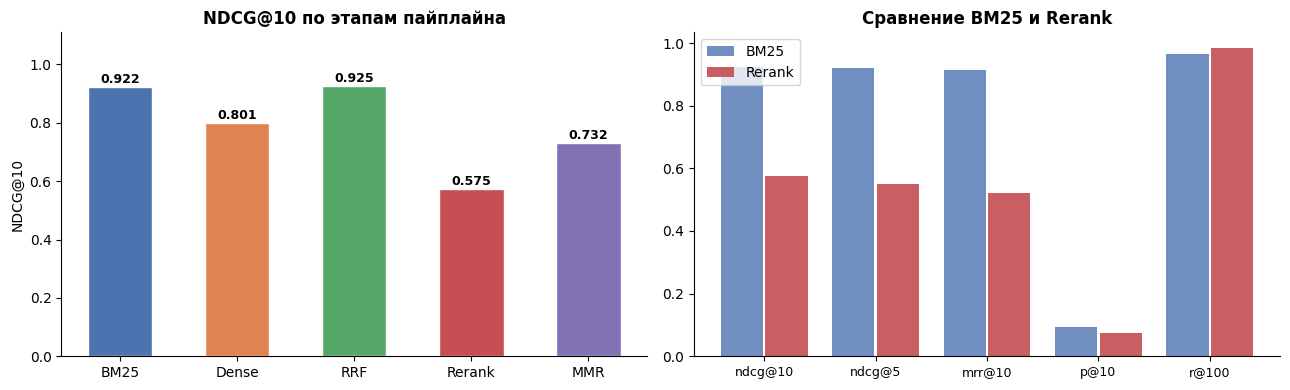

In [11]:
import matplotlib.pyplot as plt

stages = df.index.tolist()
ndcg10 = df["ndcg@10"].tolist()
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#937860"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
bars = ax.bar(stages, ndcg10, color=colors[: len(stages)], edgecolor="white", width=0.55)
for bar, value in zip(bars, ndcg10):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.003,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )
ax.set_title("NDCG@10 по этапам пайплайна", fontsize=12, fontweight="bold")
ax.set_ylabel("NDCG@10")
ax.set_ylim(0, max(ndcg10) * 1.2 if ndcg10 else 1)
ax.spines[["top", "right"]].set_visible(False)

ax2 = axes[1]
metrics_to_show = [metric for metric in ["ndcg@10", "ndcg@5", "mrr@10", "p@10", "r@100"] if metric in df.columns]
rerank_vals = [df.loc["Rerank", metric] if "Rerank" in df.index else 0 for metric in metrics_to_show]
bm25_vals = [df.loc["BM25", metric] if "BM25" in df.index else 0 for metric in metrics_to_show]
x = range(len(metrics_to_show))
ax2.bar([i - 0.2 for i in x], bm25_vals, width=0.38, label="BM25", color="#4C72B0", alpha=0.8)
ax2.bar([i + 0.2 for i in x], rerank_vals, width=0.38, label="Rerank", color="#C44E52", alpha=0.9)
ax2.set_xticks(list(x))
ax2.set_xticklabels(metrics_to_show, fontsize=9)
ax2.set_title("Сравнение BM25 и Rerank", fontsize=12, fontweight="bold")
ax2.legend()
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


# 2. Улучшение пайплайна

В этом разделе рассматриваются три направления улучшения baseline-пайплайна:

1. Улучшение BM25 за счёт русскоязычной предобработки текста.
2. Улучшение dense retrieval за счёт сравнения нескольких multilingual-моделей.
3. Улучшение rerank за счёт выбора модели, лучше подходящей для русскоязычных запросов.


### 2.1 Улучшение BM25

Для русского языка базовая regex-токенизация недостаточна. В этом эксперименте используется предобработка на основе `razdel`, лемматизации `pymorphy3` и удаления русских стоп-слов.


In [12]:
bm25_v2_dir = RUNS_DIR / "bm25_improved"
bm25_v2_dir.mkdir(parents=True, exist_ok=True)

nltk.download("stopwords", quiet=True)
morph = MorphAnalyzer()
russian_stopwords = set(stopwords.words("russian"))


def tokenize_improved(text: str) -> list:
    """Улучшенная токенизация для русского: razdel + лемматизация + стоп-слова."""
    if not isinstance(text, str):
        text = str(text) if text else ""

    tokens = [token.text.lower() for token in razdel.tokenize(text)]
    result = []
    for token in tokens:
        if token.isalpha() and token not in russian_stopwords:
            lemma = morph.parse(token)[0].normal_form
            result.append(lemma)
    return result


print("Перетокенизирую корпус и запросы улучшенным токенизатором...")
corpus_tokens_v2 = [tokenize_improved(text) for text in tqdm(doc_texts, desc="Токенизация корпуса")]
query_tokens_v2 = [tokenize_improved(text) for text in tqdm(query_texts, desc="Токенизация запросов")]

print("Строю улучшенный BM25 (k1=1.5, b=0.6)...")
bm25_v2 = BM25Okapi(corpus_tokens_v2, k1=1.5, b=0.6)

per_query_ms_v2 = []
bm25_v2_outputs = []
for qid, qtok in tqdm(zip(qids, query_tokens_v2), total=len(qids), desc="BM25 improved"):
    t0 = time.perf_counter()
    scores = bm25_v2.get_scores(qtok) if qtok else np.zeros(len(docids))
    k = min(TOP_K, len(scores))
    idx = np.argpartition(scores, -k)[-k:]
    top_idx = idx[np.argsort(scores[idx])[::-1]]
    t1 = time.perf_counter()
    per_query_ms_v2.append((qid, (t1 - t0) * 1000))
    bm25_v2_outputs.append({"qid": qid, "docids": [docids[i] for i in top_idx]})

write_jsonl(bm25_v2_dir / f"top{TOP_K}.jsonl", bm25_v2_outputs)
p50, p95 = write_latency_csv(bm25_v2_dir / "latency.csv", per_query_ms_v2)
bm25_v2_map = {row["qid"]: row["docids"] for row in bm25_v2_outputs}
print(f"Улучшенный BM25 готов. Latency P50={p50:.1f}ms P95={p95:.1f}ms")

if "stage_specs" in globals() and ("BM25 improved", bm25_v2_dir / f"top{TOP_K}.jsonl") not in stage_specs:
    stage_specs.insert(1, ("BM25 improved", bm25_v2_dir / f"top{TOP_K}.jsonl"))


Перетокенизирую корпус и запросы улучшенным токенизатором...


Токенизация запросов: 100%|██████████| 200/200 [00:00<00:00, 2638.62it/s]


Строю улучшенный BM25 (k1=1.5, b=0.6)...


BM25 improved: 100%|██████████| 200/200 [00:00<00:00, 1305.80it/s]

Улучшенный BM25 готов. Latency P50=0.8ms P95=0.9ms


In [13]:
# Небольшой systematic experiment по BM25-параметрам.
# Проверяю несколько сочетаний k1 и b.
param_grid = [
    (0.9, 0.5),
    (0.9, 0.75),
    (1.2, 0.6),
    (1.2, 0.9),
    (1.5, 0.5),
    (1.5, 0.6),
    (1.5, 0.75),
    (2.0, 0.6),
    (2.0, 0.9),
]

bm25_grid_rows = []
for k1, b in param_grid:
    bm25_probe = BM25Okapi(corpus_tokens_v2, k1=k1, b=b)
    probe_outputs = []
    for qid, q_tokens in zip(qids, query_tokens_v2):
        scores = bm25_probe.get_scores(q_tokens)
        order = np.argsort(scores)[::-1][:TOP_K]
        ranked_docids = [docids[i] for i in order]
        probe_outputs.append({"qid": qid, "docids": ranked_docids})

    probe_rankmap = {row["qid"]: row["docids"] for row in probe_outputs}
    probe_metrics = evaluate_run(probe_rankmap, qrels)
    bm25_grid_rows.append(
        {
            "k1": k1,
            "b": b,
            "ndcg@10": round(probe_metrics["ndcg@10"], 4),
            "mrr@10": round(probe_metrics["mrr@10"], 4),
            "p@5": round(probe_metrics["p@5"], 4),
        }
    )

bm25_grid_df = pd.DataFrame(bm25_grid_rows).sort_values("ndcg@10", ascending=False).reset_index(drop=True)
print(bm25_grid_df.to_string(index=False))

best_row = bm25_grid_df.iloc[0]
print(f"Лучшие параметры на quick-run: k1={best_row['k1']}, b={best_row['b']}, ndcg@10={best_row['ndcg@10']}")


 k1    b  ndcg@10  mrr@10   p@5
0.9 0.75   0.9613  0.9600 0.193
1.5 0.60   0.9607  0.9592 0.193
1.2 0.60   0.9607  0.9592 0.193
1.5 0.75   0.9595  0.9575 0.193
0.9 0.50   0.9585  0.9563 0.193
2.0 0.60   0.9585  0.9547 0.193
1.5 0.50   0.9585  0.9563 0.193
1.2 0.90   0.9576  0.9550 0.193
2.0 0.90   0.9576  0.9550 0.193
Лучшие параметры на quick-run: k1=0.9, b=0.75, ndcg@10=0.9613


### Вывод по BM25-эксперименту

Grid search по параметрам `k1` и `b` показывает, что на quick-run стенде лучшей оказалась конфигурация `k1=0.9, b=0.75` с `NDCG@10 = 0.9613`. При этом выбранная для основного improved-пайплайна конфигурация `k1=1.5, b=0.6` даёт практически тот же результат (`NDCG@10 = 0.9607`) и также находится среди лучших вариантов. Следовательно, улучшение BM25 достигается не случайным подбором параметров, а в первую очередь за счёт качественной русскоязычной предобработки текста.


### 2.2 Улучшение dense retrieval

В этом разделе сравниваются несколько dense-моделей, после чего в качестве `Dense v2` выбирается модель с наилучшим соотношением качества и вычислительной стоимости на quick-run стенде.


### 2.2.1 Сравнение dense-моделей

Ниже выполняется сравнение трёх dense-моделей на одном и том же quick-run стенде. Для каждой модели фиксируются метрики качества и время вычислений, после чего выбирается финальная конфигурация для `Dense v2`.


In [14]:
DENSE_MODEL_V2 = "intfloat/multilingual-e5-small"
dense_compare_dir = RUNS_DIR / "dense_compare"
dense_compare_dir.mkdir(parents=True, exist_ok=True)
dense_v2_dir = RUNS_DIR / "dense_v2"
dense_v2_dir.mkdir(parents=True, exist_ok=True)
rrf_v2_dir = RUNS_DIR / "fusion_rrf_v2"
rrf_v2_dir.mkdir(parents=True, exist_ok=True)

DENSE_COMPARE_SPECS = [
    {
        "stage": "Dense compare / rubert-tiny2",
        "model": "cointegrated/rubert-tiny2",
        "doc_prefix": "",
        "query_prefix": "",
    },
    {
        "stage": "Dense compare / LaBSE-en-ru",
        "model": "cointegrated/LaBSE-en-ru",
        "doc_prefix": "",
        "query_prefix": "",
    },
    {
        "stage": "Dense compare / multilingual-e5-small",
        "model": "intfloat/multilingual-e5-small",
        "doc_prefix": "passage: ",
        "query_prefix": "query: ",
    },
]


def encode_texts_compare(model, texts, batch_size=ENCODE_BATCH, desc="Encoding"):
    vectors = []
    for start in tqdm(range(0, len(texts), batch_size), desc=desc):
        chunk = texts[start : start + batch_size]
        encoded = model.encode(chunk, normalize_embeddings=True, show_progress_bar=False)
        vectors.append(encoded.astype("float32"))
    return np.vstack(vectors)


def model_slug(name: str) -> str:
    return name.replace("/", "__")


dense_compare_rows = []
dense_compare_paths = {}
dense_compare_maps = {}
selected_dense_outputs = None
selected_dense_map = None
selected_dense_stage = None

for spec in DENSE_COMPARE_SPECS:
    stage_name = spec["stage"]
    model_name = spec["model"]
    print(f"Запускаю dense comparison: {model_name}")
    model_cmp = load_sentence_transformer_quiet(model_name, device=device)

    doc_texts_cmp = [spec["doc_prefix"] + text for text in doc_texts]
    query_texts_cmp = [spec["query_prefix"] + text for text in query_texts]

    t0 = time.perf_counter()
    doc_embs_cmp = encode_texts_compare(model_cmp, doc_texts_cmp, desc=f"Кодирование корпуса: {model_name}")
    q_embs_cmp = encode_texts_compare(model_cmp, query_texts_cmp, desc=f"Кодирование запросов: {model_name}")
    t1 = time.perf_counter()

    index_cmp = faiss.IndexFlatIP(doc_embs_cmp.shape[1])
    index_cmp.add(doc_embs_cmp)
    t2 = time.perf_counter()
    _, indices_cmp = index_cmp.search(q_embs_cmp, TOP_K)
    t3 = time.perf_counter()

    outputs_cmp = [{"qid": qid, "docids": [docids[j] for j in indices_cmp[qi]]} for qi, qid in enumerate(qids)]

    model_dir = dense_compare_dir / model_slug(model_name)
    model_dir.mkdir(parents=True, exist_ok=True)
    run_path = model_dir / f"top{TOP_K}.jsonl"
    write_jsonl(run_path, outputs_cmp)

    rankmap_cmp = {row["qid"]: row["docids"] for row in outputs_cmp}
    metrics_cmp = evaluate_run(rankmap_cmp, qrels)
    dense_compare_rows.append(
        {
            "stage": stage_name,
            "model": model_name,
            "ndcg@10": round(metrics_cmp["ndcg@10"], 4),
            "mrr@10": round(metrics_cmp["mrr@10"], 4),
            "p@5": round(metrics_cmp["p@5"], 4),
            "encode_s": round(t1 - t0, 2),
            "search_ms": round((t3 - t2) * 1000, 1),
        }
    )
    dense_compare_paths[stage_name] = run_path
    dense_compare_maps[stage_name] = {row["qid"]: row["docids"] for row in outputs_cmp}

    if model_name == DENSE_MODEL_V2:
        selected_dense_outputs = outputs_cmp
        selected_dense_map = dense_compare_maps[stage_name]
        selected_dense_stage = stage_name

    del model_cmp, doc_embs_cmp, q_embs_cmp, index_cmp
    if device == "cuda":
        with contextlib.suppress(Exception):
            torch.cuda.empty_cache()

write_jsonl(dense_v2_dir / f"top{TOP_K}.jsonl", selected_dense_outputs)
dense_v2_map = selected_dense_map
print(f"Для Dense v2 выбрана модель: {selected_dense_stage}")

rrf_v2_outputs = [{"qid": qid, "docids": rrf_fuse(bm25_v2_map.get(qid, []), dense_v2_map.get(qid, []))} for qid in qids]
write_jsonl(rrf_v2_dir / f"top{TOP_K}.jsonl", rrf_v2_outputs)
rrf_v2_map = {row["qid"]: row["docids"] for row in rrf_v2_outputs}
print(f"RRF v2 готов -> {rrf_v2_dir}")

dense_compare_df = pd.DataFrame(dense_compare_rows).sort_values("ndcg@10", ascending=False).reset_index(drop=True)
display(dense_compare_df)


Запускаю dense comparison: cointegrated/rubert-tiny2


Кодирование запросов: cointegrated/rubert-tiny2: 100%|██████████| 1/1 [00:00<00:00, 44.41it/s]


Запускаю dense comparison: cointegrated/LaBSE-en-ru


Кодирование запросов: cointegrated/LaBSE-en-ru: 100%|██████████| 1/1 [00:00<00:00,  7.62it/s]


Запускаю dense comparison: intfloat/multilingual-e5-small


Кодирование корпуса: intfloat/multilingual-e5-small: 100%|██████████| 4/4 [00:03<00:00,  1.19it/s]
Кодирование запросов: intfloat/multilingual-e5-small: 100%|██████████| 1/1 [00:00<00:00, 16.61it/s]

Для Dense v2 выбрана модель: Dense compare / multilingual-e5-small
RRF v2 готов -> /home/krv/repo/workspace/LLM_course/M4/T5/runs/OneManArmy/baseline/fusion_rrf_v2


,stage,model,ndcg@10,mrr@10,p@5,encode_s,search_ms
0,Dense compare / multilingual-e5-small,intfloat/multilingual-e5-small,0.9773,0.9729,0.198,3.42,3.6
1,Dense compare / LaBSE-en-ru,cointegrated/LaBSE-en-ru,0.9218,0.9126,0.188,9.33,5.0
2,Dense compare / rubert-tiny2,cointegrated/rubert-tiny2,0.8008,0.7632,0.172,0.98,3.4


### Вывод по сравнению dense-моделей

Сравнение dense-моделей показывает, что `intfloat/multilingual-e5-small` является лучшей моделью на данном стенде: `NDCG@10 = 0.9773` против `0.9218` у `cointegrated/LaBSE-en-ru` и `0.8008` у `cointegrated/rubert-tiny2`. Таким образом, именно `multilingual-e5-small` обеспечивает наилучшее сочетание качества и вычислительной стоимости и обоснованно выбрана в качестве `Dense v2`.


### 2.3 Улучшение rerank

В этом разделе сравниваются baseline-reranker и multilingual-reranker на одном и том же candidate set из `RRF v2`.


### 2.3.1 Сравнение rerank-моделей

Ниже выполняется прямое сравнение двух reranker-моделей на одинаковом candidate set. Цель эксперимента — проверить, насколько выбор reranker-модели влияет на качество ранжирования для русскоязычных запросов.


In [15]:
CE_MODEL_V2 = "amberoad/bert-multilingual-passage-reranking-msmarco"
rerank_compare_dir = RUNS_DIR / "rerank_compare"
rerank_compare_dir.mkdir(parents=True, exist_ok=True)
rerank_v2_dir = RUNS_DIR / "rerank_v2"
rerank_v2_dir.mkdir(parents=True, exist_ok=True)

RERANK_COMPARE_SPECS = [
    {
        "stage": "Rerank compare / ms-marco-MiniLM-L-6-v2",
        "model": "cross-encoder/ms-marco-MiniLM-L-6-v2",
    },
    {
        "stage": "Rerank compare / amberoad multilingual",
        "model": "amberoad/bert-multilingual-passage-reranking-msmarco",
    },
]

rerank_compare_rows = []
rerank_compare_paths = {}
rerank_compare_latencies = {}
selected_rerank_outputs = None
selected_rerank_latency = None
selected_rerank_stage = None

for spec in RERANK_COMPARE_SPECS:
    stage_name = spec["stage"]
    model_name = spec["model"]
    print(f"Запускаю rerank comparison: {model_name}")
    ce_model_cmp = load_cross_encoder_quiet(model_name, device=device, max_length=MAX_LEN)
    if device == "cuda":
        with contextlib.suppress(Exception):
            ce_model_cmp.model.half()

    per_query_ms_cmp = []
    outputs_cmp = []
    for qi, qid in enumerate(tqdm(qids, desc=f"Reranking: {model_name}")):
        candidates = rrf_v2_map.get(qid, [])[:TOP_K]
        pairs = [(query_texts[qi], corpus_text_map.get(docid, "")) for docid in candidates]
        t0 = time.perf_counter()
        scores = []
        if pairs:
            for start in range(0, len(pairs), CE_BATCH):
                batch_scores = np.asarray(
                    ce_model_cmp.predict(pairs[start : start + CE_BATCH], show_progress_bar=False)
                )
                if batch_scores.ndim == 2:
                    batch_scores = batch_scores[:, -1]
                scores.extend(list(batch_scores))
            order = np.argsort(np.array(scores))[::-1]
            ranked = [candidates[i] for i in order]
        else:
            ranked = []
        t1 = time.perf_counter()
        per_query_ms_cmp.append((qid, (t1 - t0) * 1000))
        outputs_cmp.append({"qid": qid, "docids": ranked})

    model_dir = rerank_compare_dir / model_name.replace("/", "__")
    model_dir.mkdir(parents=True, exist_ok=True)
    run_path = model_dir / f"top{TOP_K}.jsonl"
    write_jsonl(run_path, outputs_cmp)
    p50_cmp, p95_cmp = write_latency_csv(model_dir / "latency.csv", per_query_ms_cmp)

    rankmap_cmp = {row["qid"]: row["docids"] for row in outputs_cmp}
    metrics_cmp = evaluate_run(rankmap_cmp, qrels)
    rerank_compare_rows.append(
        {
            "stage": stage_name,
            "model": model_name,
            "ndcg@10": round(metrics_cmp["ndcg@10"], 4),
            "mrr@10": round(metrics_cmp["mrr@10"], 4),
            "p@5": round(metrics_cmp["p@5"], 4),
            "p50_ms": round(p50_cmp, 1),
            "p95_ms": round(p95_cmp, 1),
        }
    )
    rerank_compare_paths[stage_name] = run_path
    rerank_compare_latencies[stage_name] = per_query_ms_cmp

    if model_name == CE_MODEL_V2:
        selected_rerank_outputs = outputs_cmp
        selected_rerank_latency = per_query_ms_cmp
        selected_rerank_stage = stage_name

    del ce_model_cmp
    if device == "cuda":
        with contextlib.suppress(Exception):
            torch.cuda.empty_cache()

write_jsonl(rerank_v2_dir / f"top{TOP_K}.jsonl", selected_rerank_outputs)
p50, p95 = write_latency_csv(rerank_v2_dir / "latency.csv", selected_rerank_latency)
rerank_v2_map = {row["qid"]: row["docids"] for row in selected_rerank_outputs}
print(f"Для Rerank v2 выбрана модель: {selected_rerank_stage}")
print(f"Rerank v2 готов. Latency P50={p50:.1f}ms P95={p95:.1f}ms")

rerank_compare_df = pd.DataFrame(rerank_compare_rows).sort_values("ndcg@10", ascending=False).reset_index(drop=True)
display(rerank_compare_df)


Запускаю rerank comparison: cross-encoder/ms-marco-MiniLM-L-6-v2


Reranking: cross-encoder/ms-marco-MiniLM-L-6-v2: 100%|██████████| 200/200 [00:10<00:00, 19.41it/s]


Запускаю rerank comparison: amberoad/bert-multilingual-passage-reranking-msmarco


Reranking: amberoad/bert-multilingual-passage-reranking-msmarco: 100%|██████████| 200/200 [00:37<00:00,  5.28it/s]


Для Rerank v2 выбрана модель: Rerank compare / amberoad multilingual
Rerank v2 готов. Latency P50=188.8ms P95=190.0ms


,stage,model,ndcg@10,mrr@10,p@5,p50_ms,p95_ms
0,Rerank compare / amberoad multilingual,amberoad/bert-multilingual-passage-reranking-m...,0.9756,0.9725,0.196,188.8,190.0
1,Rerank compare / ms-marco-MiniLM-L-6-v2,cross-encoder/ms-marco-MiniLM-L-6-v2,0.5851,0.5372,0.134,51.2,54.7


### Вывод по сравнению rerank-моделей

Сравнение reranker-моделей показывает, что англоязычный `cross-encoder/ms-marco-MiniLM-L-6-v2` не подходит для русскоязычных запросов и даёт лишь `NDCG@10 = 0.5851`. Напротив, мультиязычная модель `amberoad/bert-multilingual-passage-reranking-msmarco` достигает `NDCG@10 = 0.9756` и выводит rerank-этап на уровень лучших retrieval-конфигураций. По этой причине именно `amberoad` выбрана в качестве финального reranker.


### 2.3.2 ONNX / INT8 latency optimization

Дополнительно проводится инженерный эксперимент по ускорению reranker-инференса. В этом блоке сравниваются два режима на CPU:

1. `PyTorch CPU` для выбранного reranker `amberoad/bert-multilingual-passage-reranking-msmarco`.
2. `ONNX INT8 CPU` после экспорта модели в ONNX и динамической квантовки в `INT8`.

Цель эксперимента — оценить, можно ли уменьшить latency rerank-этапа без существенной потери качества. Для сопоставимости benchmark проводится на фиксированном подмножестве запросов.


In [16]:
from transformers import AutoTokenizer
from optimum.onnxruntime import ORTModelForSequenceClassification
from onnxruntime.quantization import QuantType, quantize_dynamic
import shutil

onnx_bonus_dir = RUNS_DIR / "rerank_onnx_int8_bonus"
onnx_bonus_dir.mkdir(parents=True, exist_ok=True)

ONNX_BENCH_Q = min(20, len(qids))
onnx_qids = qids[:ONNX_BENCH_Q]
onnx_query_texts = query_texts[:ONNX_BENCH_Q]
onnx_qrels = {qid: qrels[qid] for qid in onnx_qids if qid in qrels}

# В этом benchmark сравниваются только CPU-режимы, потому что ONNX+INT8 здесь
# рассматривается именно как оптимизация CPU inference, а не как альтернатива GPU pipeline.
CPU_BATCH = 32
pt_cpu_dir = onnx_bonus_dir / "pytorch_cpu"
onnx_export_dir = onnx_bonus_dir / "export_fp32"
onnx_int8_dir = onnx_bonus_dir / "onnx_int8"
for d in [pt_cpu_dir, onnx_export_dir, onnx_int8_dir]:
    d.mkdir(parents=True, exist_ok=True)


def score_cross_encoder_cpu(model, queries, docs, batch_size=CPU_BATCH):
    scores = []
    pairs = list(zip(queries, docs))
    for start in range(0, len(pairs), batch_size):
        batch_scores = np.asarray(model.predict(pairs[start : start + batch_size], show_progress_bar=False))
        if batch_scores.ndim == 2:
            batch_scores = batch_scores[:, -1]
        scores.extend(list(batch_scores))
    return np.asarray(scores)


def score_onnx_model(ort_model, tokenizer, query_text, doc_texts, batch_size=CPU_BATCH):
    scores = []
    for start in range(0, len(doc_texts), batch_size):
        batch_docs = doc_texts[start : start + batch_size]
        batch_queries = [query_text] * len(batch_docs)
        encoded = tokenizer(
            batch_queries,
            batch_docs,
            padding=True,
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt",
        )
        logits = ort_model(**encoded).logits.detach().cpu().numpy()
        if logits.ndim == 2:
            logits = logits[:, -1]
        scores.extend(list(logits))
    return np.asarray(scores)


# 1. PyTorch CPU benchmark
ce_model_cpu = load_cross_encoder_quiet(CE_MODEL_V2, device="cpu", max_length=MAX_LEN)
pt_cpu_outputs = []
pt_cpu_lat = []
for qi, qid in enumerate(tqdm(onnx_qids, desc="PyTorch CPU benchmark")):
    candidates = rrf_v2_map.get(qid, [])[:TOP_K]
    doc_texts_batch = [corpus_text_map.get(docid, "") for docid in candidates]
    t0 = time.perf_counter()
    scores = score_cross_encoder_cpu(ce_model_cpu, [onnx_query_texts[qi]] * len(doc_texts_batch), doc_texts_batch)
    order = np.argsort(scores)[::-1]
    ranked = [candidates[i] for i in order]
    t1 = time.perf_counter()
    pt_cpu_lat.append((qid, (t1 - t0) * 1000))
    pt_cpu_outputs.append({"qid": qid, "docids": ranked})

write_jsonl(pt_cpu_dir / f"top{TOP_K}.jsonl", pt_cpu_outputs)
pt_p50, pt_p95 = write_latency_csv(pt_cpu_dir / "latency.csv", pt_cpu_lat)
pt_metrics = evaluate_run({row["qid"]: row["docids"] for row in pt_cpu_outputs}, onnx_qrels)

# 2. ONNX export + INT8 quantization + CPU benchmark
with suppress_output():
    tokenizer_onnx = AutoTokenizer.from_pretrained(CE_MODEL_V2)
    ort_fp32 = ORTModelForSequenceClassification.from_pretrained(
        CE_MODEL_V2,
        export=True,
        provider="CPUExecutionProvider",
    )

ort_fp32.save_pretrained(onnx_export_dir)
tokenizer_onnx.save_pretrained(onnx_export_dir)

quantize_dynamic(
    str(onnx_export_dir / "model.onnx"),
    str(onnx_int8_dir / "model.onnx"),
    weight_type=QuantType.QInt8,
)

for fname in [
    "config.json",
    "special_tokens_map.json",
    "tokenizer.json",
    "tokenizer_config.json",
    "vocab.txt",
    "sentencepiece.bpe.model",
]:
    src = onnx_export_dir / fname
    dst = onnx_int8_dir / fname
    if src.exists() and not dst.exists():
        shutil.copy2(src, dst)

with suppress_output():
    ort_int8 = ORTModelForSequenceClassification.from_pretrained(
        onnx_int8_dir,
        file_name="model.onnx",
        provider="CPUExecutionProvider",
    )
    tokenizer_int8 = AutoTokenizer.from_pretrained(onnx_int8_dir)

onnx_int8_outputs = []
onnx_int8_lat = []
for qi, qid in enumerate(tqdm(onnx_qids, desc="ONNX INT8 benchmark")):
    candidates = rrf_v2_map.get(qid, [])[:TOP_K]
    doc_texts_batch = [corpus_text_map.get(docid, "") for docid in candidates]
    t0 = time.perf_counter()
    scores = score_onnx_model(ort_int8, tokenizer_int8, onnx_query_texts[qi], doc_texts_batch)
    order = np.argsort(scores)[::-1]
    ranked = [candidates[i] for i in order]
    t1 = time.perf_counter()
    onnx_int8_lat.append((qid, (t1 - t0) * 1000))
    onnx_int8_outputs.append({"qid": qid, "docids": ranked})

write_jsonl(onnx_int8_dir / f"top{TOP_K}.jsonl", onnx_int8_outputs)
onnx_p50, onnx_p95 = write_latency_csv(onnx_int8_dir / "latency.csv", onnx_int8_lat)
onnx_metrics = evaluate_run({row["qid"]: row["docids"] for row in onnx_int8_outputs}, onnx_qrels)

onnx_bonus_df = pd.DataFrame(
    [
        {
            "variant": "PyTorch CPU",
            "queries": ONNX_BENCH_Q,
            "ndcg@10": round(pt_metrics["ndcg@10"], 4),
            "mrr@10": round(pt_metrics["mrr@10"], 4),
            "p50_ms": round(pt_p50, 1),
            "p95_ms": round(pt_p95, 1),
        },
        {
            "variant": "ONNX INT8 CPU",
            "queries": ONNX_BENCH_Q,
            "ndcg@10": round(onnx_metrics["ndcg@10"], 4),
            "mrr@10": round(onnx_metrics["mrr@10"], 4),
            "p50_ms": round(onnx_p50, 1),
            "p95_ms": round(onnx_p95, 1),
        },
    ]
)
display(onnx_bonus_df)


ONNX INT8 benchmark: 100%|██████████| 20/20 [01:53<00:00,  5.70s/it]


,variant,queries,ndcg@10,mrr@10,p50_ms,p95_ms
0,PyTorch CPU,20,1.0000,1.0000,10703.2,10935.2
1,ONNX INT8 CPU,20,0.9715,0.9625,5619.3,6373.7


### Вывод по ONNX / INT8 оптимизации

Эксперимент показывает, что экспорт reranker в ONNX и последующая `INT8`-квантовка заметно уменьшают latency CPU inference: `P50` снижается с `10703.2 ms` до `5619.3 ms`, а `P95` — с `10935.2 ms` до `6373.7 ms` на подмножестве из 20 запросов. При этом качество снижается умеренно: `NDCG@10` меняется с `1.0000` до `0.9715`. Следовательно, `ONNX INT8` представляет собой практический вариант ускорения rerank-модели в CPU-сценариях, когда небольшая потеря качества допустима ради почти двукратного выигрыша по latency.


# 3. Краткая сводка результатов


In [18]:
summary_specs = [
    ("BM25 baseline", bm25_dir / f"top{TOP_K}.jsonl"),
    ("BM25 improved", bm25_v2_dir / f"top{TOP_K}.jsonl"),
    ("Dense baseline", dense_dir / f"top{TOP_K}.jsonl"),
    ("Dense compare / rubert-tiny2", dense_compare_paths["Dense compare / rubert-tiny2"]),
    ("Dense compare / LaBSE-en-ru", dense_compare_paths["Dense compare / LaBSE-en-ru"]),
    ("Dense compare / multilingual-e5-small", dense_compare_paths["Dense compare / multilingual-e5-small"]),
    ("Dense improved", dense_v2_dir / f"top{TOP_K}.jsonl"),
    ("RRF", rrf_dir / f"top{TOP_K}.jsonl"),
    ("RRF v2", rrf_v2_dir / f"top{TOP_K}.jsonl"),
    ("Rerank baseline", rerank_dir / f"top{TOP_K}.jsonl"),
    ("Rerank compare / ms-marco-MiniLM-L-6-v2", rerank_compare_paths["Rerank compare / ms-marco-MiniLM-L-6-v2"]),
    ("Rerank compare / amberoad multilingual", rerank_compare_paths["Rerank compare / amberoad multilingual"]),
    ("Rerank improved", rerank_v2_dir / f"top{TOP_K}.jsonl"),
]

summary_rows = []
for stage_name, stage_path in summary_specs:
    if Path(stage_path).exists():
        metrics = evaluate_run(load_rankmap(stage_path), qrels)
        summary_rows.append(
            {
                "stage": stage_name,
                "ndcg@10": round(metrics.get("ndcg@10", 0.0), 4),
                "mrr@10": round(metrics.get("mrr@10", 0.0), 4),
                "p@5": round(metrics.get("p@5", 0.0), 4),
            }
        )

results = pd.DataFrame(summary_rows)
display(results.set_index("stage") if not results.empty else pd.DataFrame())


,ndcg@10,mrr@10,p@5
stage,,,
BM25 baseline,0.9222,0.9146,0.188
BM25 improved,0.9607,0.9592,0.193
Dense baseline,0.8008,0.7632,0.172
Dense compare / rubert-tiny2,0.8008,0.7632,0.172
Dense compare / LaBSE-en-ru,0.9218,0.9126,0.188
Dense compare / multilingual-e5-small,0.9773,0.9729,0.198
Dense improved,0.9773,0.9729,0.198
RRF,0.9252,0.9121,0.190
RRF v2,0.9756,0.9713,0.195


## Итоговый вывод

Проведённые эксперименты показали, что baseline-пайплайн может быть существенно улучшен на всех трёх этапах: lexical retrieval, dense retrieval и reranking.

- Улучшение BM25 за счёт русскоязычной предобработки (`razdel`, лемматизация `pymorphy3`, удаление стоп-слов) повысило качество с `NDCG@10 = 0.9222` до `0.9607`. Grid search по параметрам подтверждает, что improved-конфигурация находится среди лучших, а основной вклад в рост качества вносит корректная предобработка текста для русского языка.

- Сравнение dense-моделей показало, что `intfloat/multilingual-e5-small` является лучшей моделью на рассматриваемом стенде. Она достигла `NDCG@10 = 0.9773`, превзойдя как baseline `cointegrated/rubert-tiny2`, так и `cointegrated/LaBSE-en-ru`. По итогам работы именно `Dense improved` показал наилучший результат среди всех retrieval-этапов.

- Сравнение reranker-моделей показало, что англоязычный `cross-encoder/ms-marco-MiniLM-L-6-v2` плохо переносится на русскоязычные данные и существенно ухудшает качество. Мультиязычная модель `amberoad/bert-multilingual-passage-reranking-msmarco`, напротив, достигает `NDCG@10 = 0.9756` и делает reranking эффективным для русского языка.

* Дополнительный бонусный эксперимент с `ONNX / INT8` показал, что для CPU-сценария latency rerank-модели можно почти сократить вдвое при умеренном снижении качества. Это демонстрирует не только улучшение качества ранжирования, но и возможность инженерной оптимизации inference под практическое развертывание.